# Building fair, balanced evaluation sets with `datacarve`

Reported model accuracy is only as trustworthy as the evaluation set behind it.
If the eval set is demographically skewed, overall accuracy is dominated by the
majority groups and can hide large performance gaps in minority groups.

Balancing an evaluation set across **one** attribute is easy. Balancing it across
**several attributes at once** (sex *and* race *and* income *and* age) is a hard
combinatorial problem: dropping a row changes four histograms at the same time.

[`datacarve`](https://github.com/bbonik/datacarve) solves this exactly, with mixed
integer linear programming (MILP): given a target distribution per attribute, it
selects the optimal subset of *real* rows whose marginals jointly match the
targets.

This notebook demonstrates it on the classic **Adult (census income)** dataset:

1. Load the data and look at its demographic imbalance
2. Carve a 1,000-row evaluation subset, balanced across sex, race, income and age *simultaneously*
3. Compare per-group evaluation on a random vs a balanced eval set
4. Show per-attribute custom targets (e.g. keep a realistic income ratio while balancing everything else)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

from datacarve import undersample_dataset

plt.style.use("ggplot")
RNG = np.random.default_rng(42)

## 1. The Adult dataset and its imbalance

48,842 census records. We focus on four attributes a fair evaluation would want
to control: **sex**, **race**, **income class** and **age**.


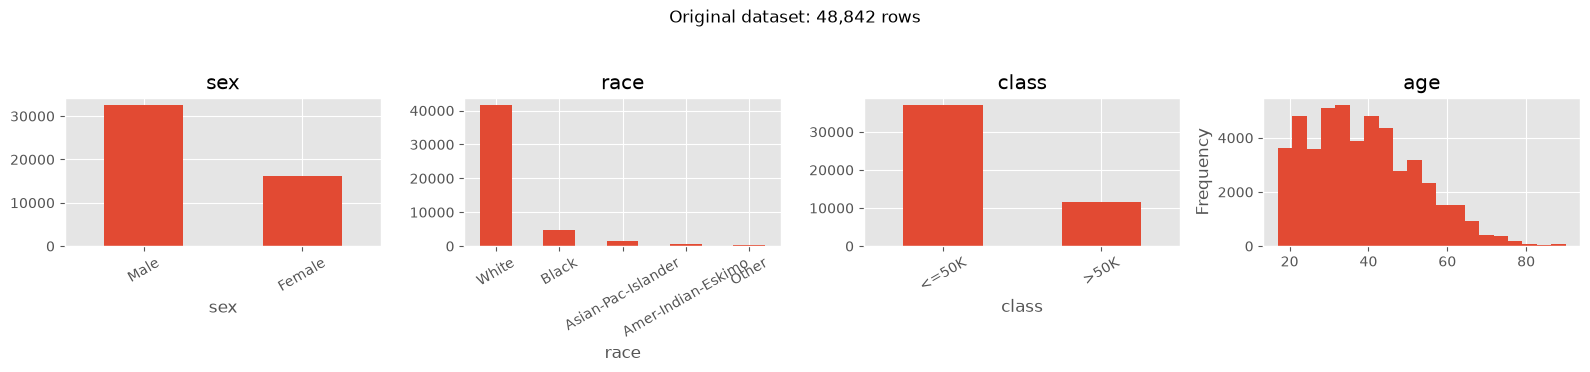

sex {'Male': 0.668, 'Female': 0.332}
race {'White': 0.855, 'Black': 0.096, 'Asian-Pac-Islander': 0.031, 'Amer-Indian-Eskimo': 0.01, 'Other': 0.008}
class {'<=50K': 0.761, '>50K': 0.239}


In [2]:
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame

attrs = ["sex", "race", "class"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, attrs):
    df[col].value_counts().plot.bar(ax=ax, title=col, rot=30)
df["age"].plot.hist(bins=20, ax=axes[3], title="age")
plt.suptitle(f"Original dataset: {len(df):,} rows", y=1.05)
plt.tight_layout()
plt.show()

for col in attrs:
    print(col, df[col].value_counts(normalize=True).round(3).to_dict())

Every attribute is skewed: twice as many men as women, 85% White, 76% low income,
and age bunched around 25–45. A random evaluation subset inherits all of this.

## 2. Carve a balanced evaluation subset

We hold out a **training partition** (first 28,000 rows) and carve the evaluation
set from the remaining ~21,000-row **evaluation pool**, so the eval rows are never
seen in training.

`datacarve` needs a numeric matrix: label-encode the categorical columns and mark
them with `categorical_dims`. A `'uniform'` target then means *equal counts per
category* for categorical attributes, and *flat histogram* for numeric age.


In [3]:
train_df = df.iloc[:28_000]
pool_df = df.iloc[28_000:].reset_index(drop=True)

pool = np.column_stack([
    pool_df["age"].to_numpy(float),
    pool_df["sex"].cat.codes.to_numpy(float),
    pool_df["race"].cat.codes.to_numpy(float),
    pool_df["class"].cat.codes.to_numpy(float),
])

mask = undersample_dataset(
    data=pool,
    data_to_keep=1000,
    target_distribution="uniform",     # balanced across ALL four attributes
    categorical_dims=[1, 2, 3],        # sex, race, income are categorical
    bins=10,                           # age is quantized into 10 bins
    solver="CBC",
    max_solver_time_sec=60,
    verbose=False,
    scatterplot_matrix=False,
)

balanced_df = pool_df[mask]
print(f"carved {mask.sum()} rows out of {len(pool_df):,}")

carved 1000 rows out of 20,842


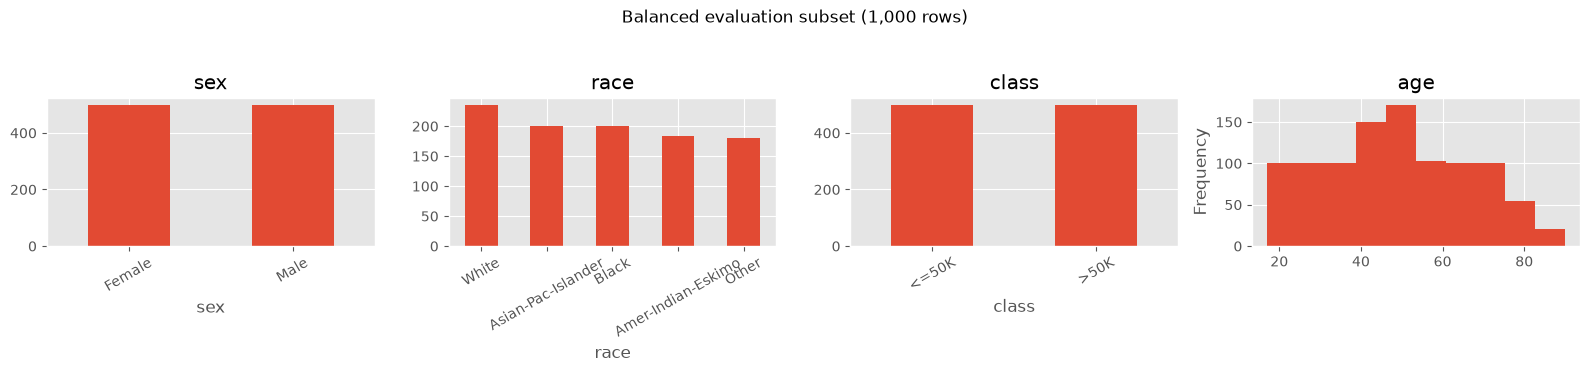

sex {'Female': 500, 'Male': 500}
race {'White': 236, 'Asian-Pac-Islander': 200, 'Black': 200, 'Amer-Indian-Eskimo': 183, 'Other': 181}
class {'<=50K': 500, '>50K': 500}


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, attrs):
    balanced_df[col].value_counts().plot.bar(ax=ax, title=col, rot=30)
balanced_df["age"].plot.hist(bins=10, ax=axes[3], title="age")
plt.suptitle("Balanced evaluation subset (1,000 rows)", y=1.05)
plt.tight_layout()
plt.show()

for col in attrs:
    print(col, balanced_df[col].value_counts().to_dict())

Exactly 500/500 on sex, 200 per race, 500/500 on income, and a flat age
histogram — **all four marginals at once**, using only real rows. No group is an
afterthought anymore: each race contributes 200 rows instead of the ~8 rows that
'Other' would get in a random 1,000-row sample.

## 3. Why this matters: evaluating a model per group

Train a simple income classifier on the training partition, then evaluate it on
(a) a **random** 1,000-row eval set and (b) our **balanced** eval set.


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

features_num = ["age", "education-num", "hours-per-week", "capital-gain", "capital-loss"]
features_cat = ["workclass", "marital-status", "occupation", "sex", "race"]

model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
    ])),
    ("clf", LogisticRegression(max_iter=1000)),
])
model.fit(train_df[features_num + features_cat], train_df["class"])

random_idx = RNG.choice(len(pool_df), size=1000, replace=False)
random_df = pool_df.iloc[random_idx]

def per_group_accuracy(eval_df, group_col):
    X = eval_df[features_num + features_cat]
    correct = model.predict(X) == eval_df["class"]
    out = correct.groupby(eval_df[group_col], observed=True).agg(["mean", "size"])
    return out.rename(columns={"mean": "accuracy", "size": "n rows"})

comparison = pd.concat(
    {
        "random eval set": per_group_accuracy(random_df, "race"),
        "balanced eval set": per_group_accuracy(balanced_df, "race"),
    },
    axis=1,
)
comparison.round(3)

random eval set        balanced eval set       
                          accuracy n rows          accuracy n rows
race                                                              
Amer-Indian-Eskimo           0.882     17             0.913    183
Asian-Pac-Islander           0.727     33             0.740    200
Black                        0.869     84             0.640    200
Other                        0.800     10             0.934    181
White                        0.824    856             0.720    236

The point is in the **`n rows` columns**. In the random eval set, the smallest
groups get a handful of rows, so their accuracy estimate is statistical noise —
a couple of lucky predictions swing it by several percentage points, and a
dashboard shows a misleading number. The balanced set gives **every group the
same 200-row evidence base**, so per-group accuracies are comparable and equally
trustworthy.

## 4. Per-attribute targets

Full uniformity is not always what you want. Suppose the eval set should keep a
**realistic 3:1 income ratio** while balancing sex exactly and shaping age —
each attribute gets its own target:


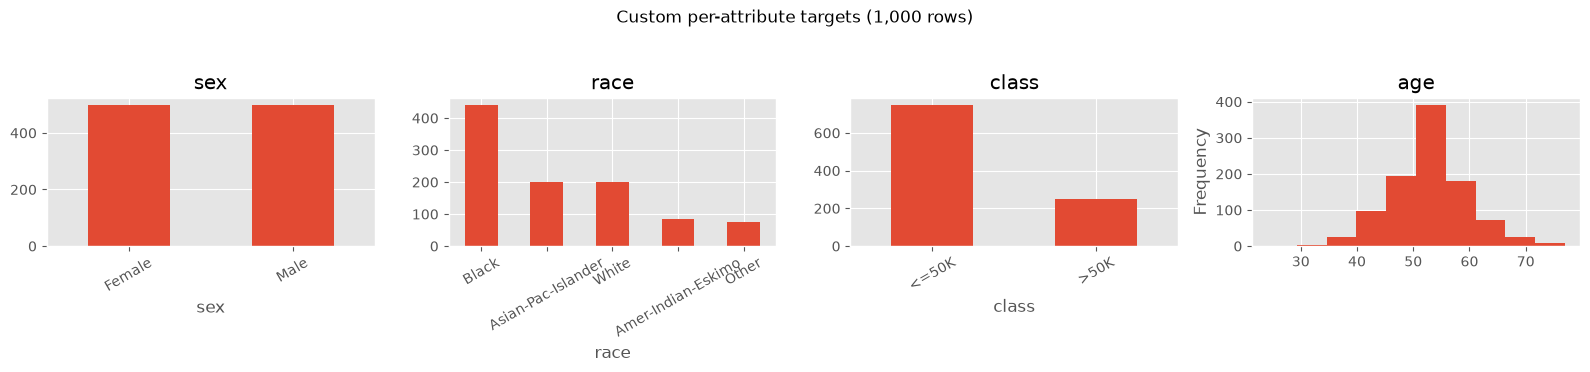

income: {'<=50K': 750, '>50K': 250}
sex: {'Female': 500, 'Male': 500}


In [6]:
mask2 = undersample_dataset(
    data=pool,
    data_to_keep=1000,
    target_distribution=[
        "gaussian",   # age: concentrated around the mid-range
        "uniform",    # sex: 500/500
        "uniform",    # race: 200 per category
        [3, 1],       # income: exact 3:1 ratio of <=50K to >50K
    ],
    categorical_dims=[1, 2, 3],
    solver="CBC",
    max_solver_time_sec=60,
    verbose=False,
    scatterplot_matrix=False,
)
custom_df = pool_df[mask2]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, attrs):
    custom_df[col].value_counts().plot.bar(ax=ax, title=col, rot=30)
custom_df["age"].plot.hist(bins=10, ax=axes[3], title="age")
plt.suptitle("Custom per-attribute targets (1,000 rows)", y=1.05)
plt.tight_layout()
plt.show()

print("income:", custom_df["class"].value_counts().to_dict())
print("sex:", custom_df["sex"].value_counts().to_dict())

## Wrap-up

- `datacarve` selected a demographically balanced evaluation set from ~21,000
  candidate rows in seconds, matching four attribute distributions **jointly** —
  something greedy or per-attribute stratification cannot guarantee.
- Targets are flexible per attribute: uniform, parametric shapes, or exact
  custom ratios.
- The same recipe applies to any multi-attribute curation problem: fine-tuning
  subsets, cohort matching, quota sampling, scenario selection.

**Install:** `pip install datacarve` &nbsp;|&nbsp; **Repo:**
<https://github.com/bbonik/datacarve>

If you use this in research, please cite:

1. Vonikakis, V., Subramanian, R., Arnfred, J., & Winkler, S. *A Probabilistic
   Approach to People-Centric Photo Selection and Sequencing.* IEEE Transactions
   in Multimedia, 11(19), pp.2609-2624, 2017.
2. Vonikakis, V., Subramanian, R., & Winkler, S. *Shaping Datasets: Optimal Data
   Selection for Specific Target Distributions.* Proc. ICIP2016.
